# Differential Gene Expression and Pathway Enrichment analysis walkthrough

In [1]:
from GeneAnalyzer import *

### Read in the anndata and the metadata

In [2]:
adata = sc.read_h5ad('/common/lamt2/HPV/data/xenium/adata/adata_features.h5ad')
metadata = pd.read_csv('/common/knottsilab/xenium/hpv/metadata.csv', index_col = 0)
metadata['Accession_no'] = metadata['Accession_no'].astype(str)

### Setup the analysis design

* `group_key`
    * This parameter defines the metadata columns in which the analysis will be performed
    * Each unique combination of values in the `group_key` columns will be an independent dataset
* `pseudobulk_key`
    * This parameter defines the metadata column used to pseudobulk the counts
    * Counts are pseudobulked within each `group_key` combination
* `comparisons`
    * Defines which metadata columns are used as covariates in the design matrix
* `skip`
    * Some group_keys have too few cells/counts or are redundant comparisons
    * Skip is a dictionary defining a list of values for a given group_key that will be skipped

In [3]:
group_key = ['primary_celltype', 'annot_region'] # Groups in which the analysis will be performed
pseudobulk_key = ['Accession_no'] # Metadata column used to aggregate counts
comparisons = ['Diagnosis'] # Metadata column
preselection = [
    'Diagnosis != "SIL_ungraded"',
    'SCC_ADENO == "SCC"',
]

# What comparisons to skip due to low counts or redundancy
skip = defaultdict(list)
skip['primary_celltype'] = ['NOS', 'muscle'] # Primary celltypes with low counts (too limited statistics for comparisons)
skip['secondary_celltype'] = ['NOS', 'muscle', 'Mast_cell', 'neural'] # Skip when primary celltype only has 1 secondary celltype
skip['tertiary_celltype'] = ['NOS', 'muscle', 'Mast_cell', 'neural', 'Epithelial', 'Epithelial_glandular', 'Epithelial_mixed', 'Epithelium_neuroendocrine', 'NK_gdT', 'pDC'] # Skip when secondary celltype only has 1 tertiary celltype


### Make the gene analyzer

In [4]:
# The gene analyzer can also take a design and null design formula as optional parameters
# These are used when using the log-likelihood ratio test. If using the LRT with no provided designs,
# the full design formula will be all comparisons + interactions and the null design will be constant (~1)
analyzer = GeneAnalyzer(adata, pseudobulk_key, group_key, comparisons, metadata = metadata, preselection = preselection, skip = skip)

### Run the initial analysis (without permutations)

The `run_analysis()` function optionally takes a contrast as input. If no contrast is provided, the analyzer performs a likelihood-ratio test comparing the full model to a reduced model

If a contrast is provided, the analyzer will use a wald test and calculate the log-fold change and standard errors.

The contrast can either be a numpy array or a dictionary containing `test` and `ref` keys defining the test and reference classes. Using a dictionary is preferred since the design matrix column order can change between groups

In [5]:
contrast = {
    'test': dict(Diagnosis = 'No_SIL'),
    'ref': dict(Diagnosis = 'Invasive')
}

res = analyzer.run_analysis(
    # contrast = contrast,
)

Pseudobulking anndata ... done: 0.19 min


Fitting OLS to GSVA scores for ('neural', '3'): 100%|██████████| 14/14 [00:02<00:00,  6.15it/s]   


### Look at the initial statistical output

* `index`: All information on gene/pathway and which group keys are being used
* `feature`: column containing the gene or pathway
* `stat`: column containing the test statistic (either wald or likelihood ratio)
* `pvalue`: Column calculated from the asymptotic behavior of the test stat
    * For the likelihood ratio test, the statistic follows a chi2 distribution with degrees of freedom equal to the full - reduced model dimensionality
    * For the wald test, the statistic follows a chi2 distribution with 1 degree of freedom
* `padj`: Column containing adjusted p-values. These are created from the deseq2 pipeline but should not be used for downstream analysis because they don't fully account for the FDR corrections
    * For deseq2 analysis, the correction is applied within each group and depends on the `indepdendent_filter` parameter
    * For the gsva analysis, the correction is a simple BH correction across all pathway analyses

In [6]:
res

,feature,stat,pvalue,padj,primary_celltype,annot_region,feature_type
index,,,,,,,
A2ML1___primary_celltype__B_plasma___annot_region__2,A2ML1,29.689746,1.603793e-06,0.000008,B_plasma,2,gene
AAMP___primary_celltype__B_plasma___annot_region__2,AAMP,32.451724,4.203096e-07,0.000002,B_plasma,2,gene
AAR2___primary_celltype__B_plasma___annot_region__2,AAR2,4.397113,2.216532e-01,0.318404,B_plasma,2,gene
AARSD1___primary_celltype__B_plasma___annot_region__2,AARSD1,2.157019,5.404638e-01,0.654977,B_plasma,2,gene
ABAT___primary_celltype__B_plasma___annot_region__2,ABAT,2.090916,5.537528e-01,0.668166,B_plasma,2,gene
...,...,...,...,...,...,...,...
HALLMARK_UNFOLDED_PROTEIN_RESPONSE___primary_celltype__neural___annot_region__3,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,19.327284,2.339373e-04,0.001604,neural,3,pathway
HALLMARK_UV_RESPONSE_DN___primary_celltype__neural___annot_region__3,HALLMARK_UV_RESPONSE_DN,13.659384,3.407435e-03,0.012581,neural,3,pathway
HALLMARK_UV_RESPONSE_UP___primary_celltype__neural___annot_region__3,HALLMARK_UV_RESPONSE_UP,0.902231,8.248894e-01,0.824889,neural,3,pathway


### Run the permutation tests to calculate empirical p-values

Similar to the feature extraction code, we use permutation tests to generate null distributions for each feature

Usually I will aim for >=1000 permutations but we will only use ~100 to keep the tutorial quick (drop to 10 if this takes too much time). This step will take longer than expected since pydeseq2 and gsva are threaded by default, but due to joblib's multiprocessing will only be given 1 thread since each of the parallel jobs is serialized

Setting the random state is important so we can get the correlations between features from different runs (e.g. secondary celltypes, etc.)

In [7]:
# Set n_permutations based on number of avail cpus
# By default the analyzer will use ncpus - 1 for all jobs
res = analyzer.run_stats_with_permutations(n_permutations = multiprocessing.cpu_count() * 3 - 3, random_state = 42)

Calculating permutations:   0%|          | 0/141 [00:00<?, ?it/s]/common/lamt2/src/PyDESeq2/pydeseq2/dds.py:432: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst=True)
/common/lamt2/src/PyDESeq2/pydeseq2/dds.py:432: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst=True)
/common/lamt2/src/PyDESeq2/pydeseq2/dds.py:432: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst=True)
/common/lamt2/src/PyDESeq2/pydeseq2/dds.py:432: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst=True)
/common/lamt2/src/PyDESeq2/pydeseq2/dds.py:432: UserWarning: The dispersion trend curve fitting did not

The stats object has two keys: one for the dataframe containing the empirical p-values and another for the permutations

In [8]:
res.keys()

dict_keys(['df', 'perm_df'])

Print the dataframe with the p-values

In [9]:
res['df']

,feature,stat,pvalue,padj,primary_celltype,annot_region,feature_type,p-nom
index,,,,,,,,
A2ML1___primary_celltype__B_plasma___annot_region__2,A2ML1,29.689746,1.603793e-06,0.000008,B_plasma,2,gene,0.084507
AAMP___primary_celltype__B_plasma___annot_region__2,AAMP,32.451724,4.203096e-07,0.000002,B_plasma,2,gene,0.007042
AAR2___primary_celltype__B_plasma___annot_region__2,AAR2,4.397113,2.216532e-01,0.318404,B_plasma,2,gene,0.140845
AARSD1___primary_celltype__B_plasma___annot_region__2,AARSD1,2.157019,5.404638e-01,0.654977,B_plasma,2,gene,0.295775
ABAT___primary_celltype__B_plasma___annot_region__2,ABAT,2.090916,5.537528e-01,0.668166,B_plasma,2,gene,0.464789
...,...,...,...,...,...,...,...,...
HALLMARK_UNFOLDED_PROTEIN_RESPONSE___primary_celltype__neural___annot_region__3,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,19.327284,2.339373e-04,0.001604,neural,3,pathway,0.042254
HALLMARK_UV_RESPONSE_DN___primary_celltype__neural___annot_region__3,HALLMARK_UV_RESPONSE_DN,13.659384,3.407435e-03,0.012581,neural,3,pathway,0.035211
HALLMARK_UV_RESPONSE_UP___primary_celltype__neural___annot_region__3,HALLMARK_UV_RESPONSE_UP,0.902231,8.248894e-01,0.824889,neural,3,pathway,0.971831


### Now we run the FDR corrections using the Benjamini-Bogomolov method

This is identical to the feature extraction code with one exception. DESeq2 can filter out p-values using the independent_filtering parameter. We respect this filtering and exclude those genes from the analysis

Running Benjamini-Bogomolov selection criteria based on permutation clusters


Calculating correlation matrix:   0%|          | 0/54143 [00:00<?, ?it/s]

   Calculating Distance and linkage matrix ... done: 1.90 min


Calculating silhouette scores: 100%|██████████| 100/100 [12:54<00:00,  7.75s/it]

   Clustering at threshold t = 0.828


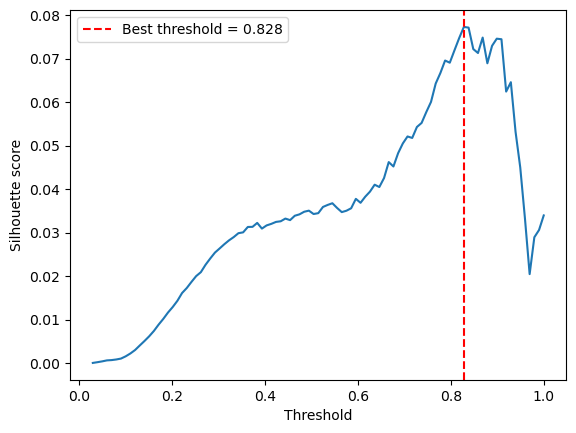

Calculating final FDR q-values: 100%|██████████| 1001/1001 [00:00<00:00, 1001.12it/s]


Done with FDR corrections: 15.57 min


In [10]:
stat_res = run_fdr_corrections(res['perm_df'], res['df'][~res['df']['padj'].isna()], plot_threshold = True, n_jobs = 5)

### Look at the new columns added to the dataframe

* cluster: The cluster label from feature clustering
* p-simes: The simes p-value for each cluster
* p-simes-adj: The BH correct simes p-values
* cluster-p-adj: The empirical p-value with BH correction within each p-value
* fdr-q-val: The significance level alpha at which a feature would be declared significant
* signif: Boolean value indicating feature significance < alpha (default 0.05)

In [24]:
stat_res[stat_res['feature_type'] == 'gene'].sort_values('fdr-q-val').head(5)

,feature,stat,pvalue,padj,primary_celltype,annot_region,feature_type,p-nom,cluster,p-simes,p-simes-adj,cluster-p-adj,fdr-q-val,signif
index,,,,,,,,,,,,,,
LARP4___primary_celltype__TNK___annot_region__3,LARP4,28.603954,2.712314e-06,7.099059e-06,TNK,3,gene,0.007042,515,0.008351,0.037099,0.008351,0.038,True
LIG3___primary_celltype__TNK___annot_region__3,LIG3,11.419759,9.659713e-03,1.617196e-02,TNK,3,gene,0.007042,515,0.008351,0.037099,0.008351,0.038,True
LGALS8___primary_celltype__TNK___annot_region__3,LGALS8,52.316693,2.563953e-11,1.218304e-10,TNK,3,gene,0.007042,515,0.008351,0.037099,0.008351,0.038,True
LENG8___primary_celltype__TNK___annot_region__3,LENG8,157.889333,5.231284e-34,5.941638e-32,TNK,3,gene,0.007042,515,0.008351,0.037099,0.008351,0.038,True
LDLR___primary_celltype__TNK___annot_region__3,LDLR,31.380671,7.067673e-07,1.983360e-06,TNK,3,gene,0.007042,515,0.008351,0.037099,0.008351,0.038,True


In [12]:
stat_res[stat_res['feature_type'] == 'pathway'].sort_values('fdr-q-val').head(5)

,feature,stat,pvalue,padj,primary_celltype,annot_region,feature_type,p-nom,cluster,p-simes,p-simes-adj,cluster-p-adj,fdr-q-val,signif
index,,,,,,,,,,,,,,
HALLMARK_WNT_BETA_CATENIN_SIGNALING___primary_celltype__B_plasma___annot_region__2,HALLMARK_WNT_BETA_CATENIN_SIGNALING,24.534212,1.932046e-05,4.391014e-05,B_plasma,2,pathway,0.007042,2026,0.011496,0.037099,0.011496,0.038,True
HALLMARK_COAGULATION___primary_celltype__Myeloid___annot_region__2,HALLMARK_COAGULATION,43.950640,1.546062e-09,7.730309e-09,Myeloid,2,pathway,0.007042,46,0.009390,0.037099,0.009390,0.038,True
HALLMARK_UV_RESPONSE_UP___primary_celltype__B_plasma___annot_region__2,HALLMARK_UV_RESPONSE_UP,48.477509,1.685192e-10,1.685192e-09,B_plasma,2,pathway,0.007042,2026,0.011496,0.037099,0.011496,0.038,True
HALLMARK_UNFOLDED_PROTEIN_RESPONSE___primary_celltype__B_plasma___annot_region__2,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,49.992013,8.020532e-11,1.441534e-09,B_plasma,2,pathway,0.007042,2026,0.011496,0.037099,0.011496,0.038,True
HALLMARK_SPERMATOGENESIS___primary_celltype__B_plasma___annot_region__2,HALLMARK_SPERMATOGENESIS,23.773920,2.784730e-05,5.801520e-05,B_plasma,2,pathway,0.007042,2026,0.011496,0.037099,0.011496,0.038,True


### Plot a significantly gene and pathway to check

<Axes: title={'center': 'LARP4'}, xlabel='classification', ylabel='Normalized Counts'>

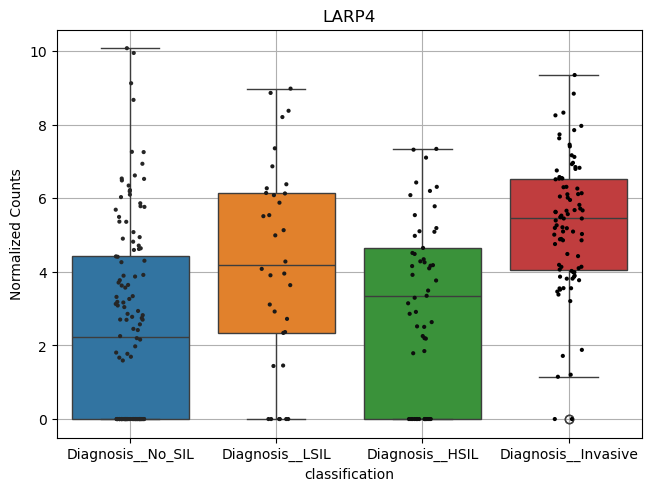

In [13]:
order = [f'Diagnosis__{d}' for d in ['No_SIL', 'LSIL', 'HSIL', 'Invasive']]
analyzer.plot_feature('LARP4___primary_celltype__TNK___annot_region__3', order = order)

<Axes: xlabel='classification', ylabel='GSVA Enrichment Score'>

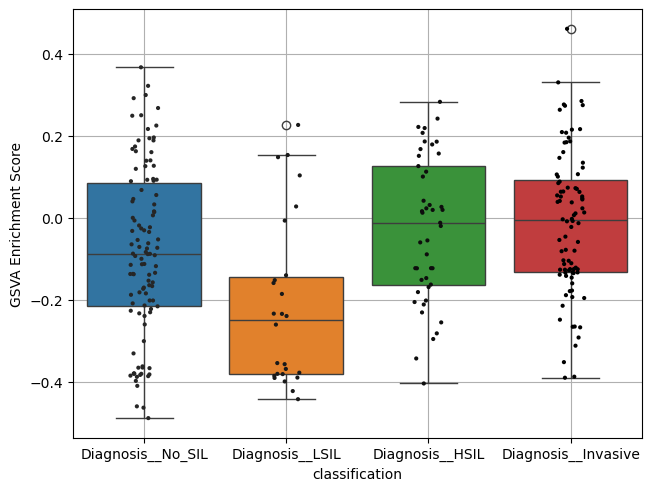

In [14]:
analyzer.plot_feature('HALLMARK_WNT_BETA_CATENIN_SIGNALING___primary_celltype__B_plasma___annot_region__2', order = order)

### Posthoc pairwise comparisons

Similar to the feature comparisons, the log-likelihood ratio test only determines if the feature as a whole shows significant differences between cohorts. If we want to extract which pairs of features are significant, we have to do the same process for each pair of comparisons.

First make all of the contrasts

In [15]:
contrasts = []
for c1, c2 in combinations(['No_SIL', 'LSIL', 'HSIL', 'Invasive'], 2):
    # Dictionaries defining the reference and test group
    ref = dict(Diagnosis = c1)
    test = dict(Diagnosis = c2)
    # Dictionary to hold contrast results
    meta = {'test': test, 'ref': ref}
    contrasts.append(meta)
contrasts

[{'test': {'Diagnosis': 'LSIL'}, 'ref': {'Diagnosis': 'No_SIL'}},
 {'test': {'Diagnosis': 'HSIL'}, 'ref': {'Diagnosis': 'No_SIL'}},
 {'test': {'Diagnosis': 'Invasive'}, 'ref': {'Diagnosis': 'No_SIL'}},
 {'test': {'Diagnosis': 'HSIL'}, 'ref': {'Diagnosis': 'LSIL'}},
 {'test': {'Diagnosis': 'Invasive'}, 'ref': {'Diagnosis': 'LSIL'}},
 {'test': {'Diagnosis': 'Invasive'}, 'ref': {'Diagnosis': 'HSIL'}}]

Now run each pairwise comparison.

For some comparisons there aren't many patients and several genes get filtered for some of the groups. In these cases, it's possible that there aren't enough genes in the pathway so GSVA can't run

Normally we would also do permutation testing to get empirical p-values but for this tutorial we're just using the asymptotic behavior of the wald test to get the p-values

In [16]:
pairwise_stat_res = {}
for contrast in (pbar:=tqdm(contrasts)):
    name = "___".join([f'{x}__{c[x]}' for key, c in contrast.items() for x in c])
    pbar.set_description(name)
    sub_preselection = [
        # Filter the dataframe so only the two groups in the contrast remain
        " | ".join([f'({x} == "{c[x]}")' for key, c in contrast.items() for x in c]),
        'SCC_ADENO == "SCC"'
    ]
    GA = GeneAnalyzer(
        adata,
        pseudobulk_key,
        group_key,
        comparisons,
        metadata,
        preselection=sub_preselection,
        skip = skip
    )
    
    pairwise_stat_res[name] = GA.run_analysis(contrast=contrast, show_progress=False)
    #pairwise_stat_res[name] = GA.run_stats_with_permutations(contrast = contrast, n_permutations = 1000, random_state = 42)
    

Diagnosis__HSIL___Diagnosis__LSIL:  50%|█████     | 3/6 [03:53<04:00, 80.11s/it]      /common/lamt2/src/PyDESeq2/pydeseq2/dds.py:432: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst=True)
2026-01-13 14:10:37,377 [ERROR] No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.

2026-01-13 14:10:37,378 [ERROR] The first entry of your gene_sets (gmt) look like this : { HALLMARK_TNFA_SIGNALING_VIA_NFKB: [ABCA1, ACKR3, AREG, ATF3, ATP2B1, B4GALT1, B4GALT5, BCL2A1, BCL3, BCL6, BHLHE40, BIRC2, BIRC3, BMP2, BTG1, BTG2, BTG3, CCL2, CCL20, CCL4, CCL5, CCN1, CCND1, CCNL1, CCRL2, CD44, CD69, CD80, CD83, CDKN1A, CEBPB, CEBPD, CFLAR, CLCF1, CSF1, CSF2, CXCL1, CXCL10, CXCL11, CXCL2, CXCL3, CXCL6, DENND5A, DNAJB4, DRAM

   GSVA fitting failed: No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.



Diagnosis__Invasive___Diagnosis__HSIL: 100%|██████████| 6/6 [07:29<00:00, 74.90s/it]


Make the dataframe for the posthoc comparisons and do FDR correction within each comparison (not using the BB fdr method, since we're doing these comparisons post-hoc)

In [17]:
posthoc_df = pd.DataFrame()

for key in pairwise_stat_res:
    tmp_df = pairwise_stat_res[key].copy()
    tmp_df['group1'] = key.split('___')[0]
    tmp_df['group2'] = key.split('___')[1]
    posthoc_df = pd.concat([posthoc_df, tmp_df], axis = 0, join = 'outer')
posthoc_df = posthoc_df[~posthoc_df['padj'].isna()].copy()
posthoc_df = posthoc_df.reset_index()
posthoc_df = posthoc_df.drop('feature', axis = 1)
posthoc_df = posthoc_df.rename(columns = {'index': 'feature'})

posthoc_df['fdr-q-val'] = posthoc_df.groupby('feature')['pvalue'].transform(lambda x: false_discovery_control(x))

In [18]:
posthoc_df

,feature,effect,effectSE,stat,pvalue,padj,primary_celltype,annot_region,feature_type,group1,group2,fdr-q-val
0,AAMP___primary_celltype__B_plasma___annot_regi...,-1.096162,0.386132,-2.838824,0.004528,0.018432,B_plasma,2,gene,Diagnosis__LSIL,Diagnosis__No_SIL,0.005434
1,ABCA1___primary_celltype__B_plasma___annot_reg...,-1.039926,0.477958,-2.175766,0.029573,0.052117,B_plasma,2,gene,Diagnosis__LSIL,Diagnosis__No_SIL,0.044359
2,ABCA7___primary_celltype__B_plasma___annot_reg...,-0.674157,0.374791,-1.798755,0.072057,0.098207,B_plasma,2,gene,Diagnosis__LSIL,Diagnosis__No_SIL,0.086469
3,ABCC1___primary_celltype__B_plasma___annot_reg...,-0.853392,0.330253,-2.584060,0.009764,0.027726,B_plasma,2,gene,Diagnosis__LSIL,Diagnosis__No_SIL,0.011717
4,ABCF3___primary_celltype__B_plasma___annot_reg...,-0.785344,0.420658,-1.866940,0.061910,0.087457,B_plasma,2,gene,Diagnosis__LSIL,Diagnosis__No_SIL,0.074292
...,...,...,...,...,...,...,...,...,...,...,...,...
307449,HALLMARK_UNFOLDED_PROTEIN_RESPONSE___primary_c...,0.155873,0.051082,9.311086,0.002977,0.009993,neural,3,pathway,Diagnosis__Invasive,Diagnosis__HSIL,0.013890
307450,HALLMARK_UV_RESPONSE_DN___primary_celltype__ne...,0.048118,0.026094,3.400432,0.068398,0.113633,neural,3,pathway,Diagnosis__Invasive,Diagnosis__HSIL,0.170995
307451,HALLMARK_UV_RESPONSE_UP___primary_celltype__ne...,0.011897,0.030113,0.156090,0.693696,0.708777,neural,3,pathway,Diagnosis__Invasive,Diagnosis__HSIL,0.717663
307452,HALLMARK_WNT_BETA_CATENIN_SIGNALING___primary_...,0.053709,0.040481,1.760282,0.187873,0.238650,neural,3,pathway,Diagnosis__Invasive,Diagnosis__HSIL,0.469683


Text(0.5, 0.98, 'HALLMARK_WNT_BETA_CATENIN_SIGNALING___primary_celltype__B_plasma___annot_region__2')

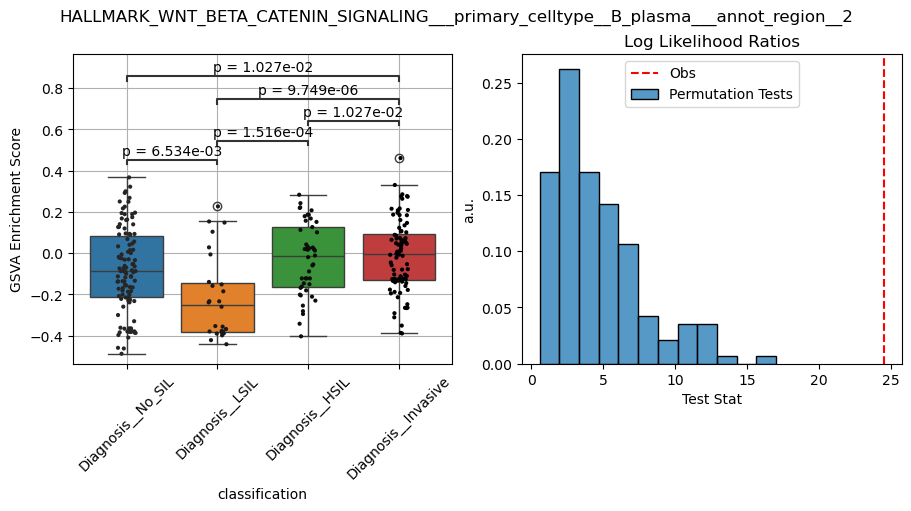

In [22]:
feature = 'HALLMARK_WNT_BETA_CATENIN_SIGNALING___primary_celltype__B_plasma___annot_region__2'

fig, ax = plt.subplots(1, 2, figsize = (9, 5), constrained_layout = True)
plot_posthoc_gene_analyzer(analyzer, posthoc_df, feature, order = order, ax = ax[0])
plot_test_stat(res['perm_df'], stat_res, feature, ax = ax[1])
fig.suptitle(feature)